# 00 — Debug: Inspect Prompts & Responses

Shows the **exact prompt**, **formatted input**, and **raw model response** for one sample per (task, modality) combination. Use this to verify that the correct data reaches the model and no labels/IDs leak.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from scripts.zeroshot_llama import (
    PROMPTS, load_data, build_messages, predict_single,
    load_model, parse_response, INFO_ID2LABEL, HUMA_ID2LABEL,
)
from PIL import Image as PILImage
from IPython.display import display, HTML, Markdown

MODEL_ID = "meta-llama/Llama-3.2-11B-Vision-Instruct"
DATA_ROOT = os.path.abspath("../data")

model, processor = load_model(MODEL_ID)

Loading model: meta-llama/Llama-3.2-11B-Vision-Instruct


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Model loaded on cuda:0


In [2]:
def debug_sample(task, modality):
    """Run one sample and display full details."""
    id2label = INFO_ID2LABEL if task == "informative" else HUMA_ID2LABEL

    # Load first sample
    _, data = load_data(task, modality, "test", DATA_ROOT)
    item = data[0]

    # Load image if needed
    image_obj = None
    if modality in ("image_only", "text_image") and item.get("image_path"):
        img = PILImage.open(item["image_path"])
        image_obj = img.convert("RGBA").convert("RGB") if img.mode == "P" else img.convert("RGB")

    # Build prompt
    prompt = PROMPTS[(task, modality)]
    messages, images = build_messages(
        prompt, task, text=item.get("tweet_text"), image_obj=image_obj, modality=modality,
    )

    # Get formatted input
    input_text = processor.apply_chat_template(messages, add_generation_prompt=True)

    # Run prediction
    pred_label, raw_output = predict_single(model, processor, messages, images, task)

    # Display everything
    display(Markdown(f"---\n## {task.upper()} / {modality}"))

    # Input data
    display(Markdown("### 1. Input Data (from TSV)"))
    html = "<table>"
    for k, v in item.items():
        val = str(v)
        if len(val) > 200:
            val = val[:200] + "..."
        html += f"<tr><td><b>{k}</b></td><td><code>{val}</code></td></tr>"
    html += "</table>"
    display(HTML(html))

    # Show image if loaded
    if image_obj:
        display(Markdown("### 2. Image Sent to Model"))
        display(image_obj.resize((300, 300)))

    # Prompt text
    display(Markdown("### 3. Prompt Text (what the model sees)"))
    for msg in messages:
        for part in msg["content"]:
            if part["type"] == "text":
                display(HTML(f"<pre style='white-space:pre-wrap;background:#f5f5f5;padding:12px;border-radius:8px;font-size:12px;max-height:400px;overflow:auto'>{part['text']}</pre>"))
            elif part.get("type") == "image":
                display(HTML("<div style='padding:8px;background:#e8f0fe;border-radius:6px;display:inline-block'>&#x1F5BC; [IMAGE TOKEN]</div>"))

    # Formatted input
    display(Markdown("### 4. Formatted Input (after apply_chat_template)"))
    display(HTML(f"<pre style='white-space:pre-wrap;background:#fff8e1;padding:12px;border-radius:8px;font-size:11px;max-height:300px;overflow:auto'>{input_text}</pre>"))

    # Raw response
    display(Markdown("### 5. Model Response"))
    display(HTML(f"<pre style='white-space:pre-wrap;background:#e8f5e9;padding:12px;border-radius:8px;font-size:12px'>{raw_output}</pre>"))

    # Result
    correct = pred_label == item["class_label"]
    color = "#4caf50" if correct else "#f44336"
    display(HTML(f"""
    <table style='margin-top:8px'>
    <tr><td><b>Parsed label</b></td><td><code>{pred_label}</code></td></tr>
    <tr><td><b>Gold label</b></td><td><code>{item['class_label']}</code></td></tr>
    <tr><td><b>Correct</b></td><td style='color:{color};font-weight:bold'>{"YES" if correct else "NO"}</td></tr>
    </table>
    """))

    # Label mapping
    display(Markdown("### 6. Label Mapping"))
    mapping = " | ".join(f"`{k}` -> `{v}`" for k, v in id2label.items())
    display(Markdown(mapping))

## Informative — Text Only

In [3]:
debug_sample("informative", "text_only")

Loaded 1534 samples from D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\tasks\informative\text_only\test.tsv


---
## INFORMATIVE / text_only

### 1. Input Data (from TSV)

tweet_id,878185882431389696
tweet_text,Cristofer CLEMENTE MORA now in 2nd at aguille du posettes. He's hunting âš¡ï¸ #MontBlancMarathon 80k https://t.co/D7NLD18qWz
class_label,not_informative


### 3. Prompt Text (what the model sees)

### 4. Formatted Input (after apply_chat_template)

### 5. Model Response

Parsed label,not_informative
Gold label,not_informative
Correct,YES


### 6. Label Mapping

`0` -> `not_informative` | `1` -> `informative`

## Informative — Image Only

Loaded 1534 samples from D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\tasks\informative\image_only\test.tsv


---
## INFORMATIVE / image_only

### 1. Input Data (from TSV)

image_id,878185882431389696_0
image_path,D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\data_image\srilanka_floods\23_6_2017\878185882431389696_0.jpg
class_label,not_informative


### 2. Image Sent to Model

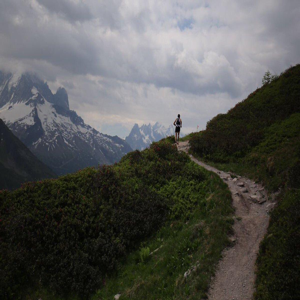

### 3. Prompt Text (what the model sees)

### 4. Formatted Input (after apply_chat_template)

### 5. Model Response

Parsed label,not_informative
Gold label,not_informative
Correct,YES


### 6. Label Mapping

`0` -> `not_informative` | `1` -> `informative`

In [4]:
debug_sample("informative", "image_only")

## Informative — Text + Image

Loaded 1534 samples from D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\tasks\informative\text_image\test.tsv


---
## INFORMATIVE / text_image

### 1. Input Data (from TSV)

tweet_id,878185882431389696
image_id,878185882431389696_0
tweet_text,Cristofer CLEMENTE MORA now in 2nd at aguille du posettes. He's hunting âš¡ï¸ #MontBlancMarathon 80k https://t.co/D7NLD18qWz
image_path,D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\data_image\srilanka_floods\23_6_2017\878185882431389696_0.jpg
class_label,not_informative


### 2. Image Sent to Model

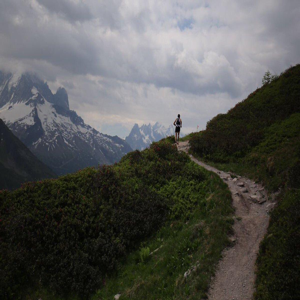

### 3. Prompt Text (what the model sees)

### 4. Formatted Input (after apply_chat_template)

### 5. Model Response

Parsed label,informative
Gold label,not_informative
Correct,NO


### 6. Label Mapping

`0` -> `not_informative` | `1` -> `informative`

In [5]:
debug_sample("informative", "text_image")

## Humanitarian — Text Only

In [6]:
debug_sample("humanitarian", "text_only")

Loaded 955 samples from D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\tasks\humanitarian\text_only\test.tsv


---
## HUMANITARIAN / text_only

### 1. Input Data (from TSV)

tweet_id,905952332923338752
tweet_text,.@Lendio has a great event tomorrow for both #BYU and #Utah fans to support Hurricane Harvey relief. https://t.co/nL2ZzKEIfy
class_label,rescue_volunteering_or_donation_effort


### 3. Prompt Text (what the model sees)

### 4. Formatted Input (after apply_chat_template)

### 5. Model Response

Parsed label,rescue_volunteering_or_donation_effort
Gold label,rescue_volunteering_or_donation_effort
Correct,YES


### 6. Label Mapping

`0` -> `affected_individuals` | `1` -> `rescue_volunteering_or_donation_effort` | `2` -> `infrastructure_and_utility_damage` | `3` -> `other_relevant_information` | `4` -> `not_humanitarian`

## Humanitarian — Image Only

Loaded 955 samples from D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\tasks\humanitarian\image_only\test.tsv


---
## HUMANITARIAN / image_only

### 1. Input Data (from TSV)

image_id,905952332923338752_0
image_path,D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\data_image\hurricane_harvey\8_9_2017\905952332923338752_0.jpg
class_label,rescue_volunteering_or_donation_effort


### 2. Image Sent to Model

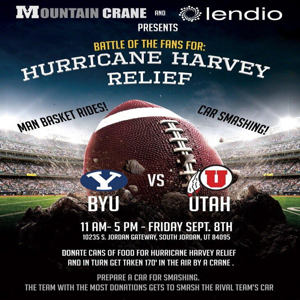

### 3. Prompt Text (what the model sees)

### 4. Formatted Input (after apply_chat_template)

### 5. Model Response

Parsed label,not_humanitarian
Gold label,rescue_volunteering_or_donation_effort
Correct,NO


### 6. Label Mapping

`0` -> `affected_individuals` | `1` -> `rescue_volunteering_or_donation_effort` | `2` -> `infrastructure_and_utility_damage` | `3` -> `other_relevant_information` | `4` -> `not_humanitarian`

In [7]:
debug_sample("humanitarian", "image_only")

## Humanitarian — Text + Image

Loaded 955 samples from D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\tasks\humanitarian\text_image\test.tsv


---
## HUMANITARIAN / text_image

### 1. Input Data (from TSV)

tweet_id,905952332923338752
image_id,905952332923338752_0
tweet_text,.@Lendio has a great event tomorrow for both #BYU and #Utah fans to support Hurricane Harvey relief. https://t.co/nL2ZzKEIfy
image_path,D:\Workspace\Cotrain_CrisisMMD\data\CrisisMMD\data_image\hurricane_harvey\8_9_2017\905952332923338752_0.jpg
class_label,rescue_volunteering_or_donation_effort


### 2. Image Sent to Model

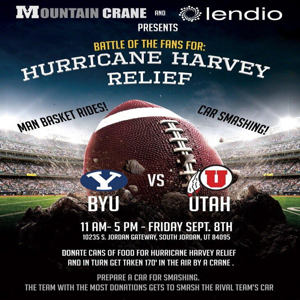

### 3. Prompt Text (what the model sees)

### 4. Formatted Input (after apply_chat_template)

### 5. Model Response

Parsed label,not_humanitarian
Gold label,rescue_volunteering_or_donation_effort
Correct,NO


### 6. Label Mapping

`0` -> `affected_individuals` | `1` -> `rescue_volunteering_or_donation_effort` | `2` -> `infrastructure_and_utility_damage` | `3` -> `other_relevant_information` | `4` -> `not_humanitarian`

In [8]:
debug_sample("humanitarian", "text_image")

## Cleanup

In [9]:
import gc, torch

del model, processor
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed. Allocated: {torch.cuda.memory_allocated()/1e9:.1f} GB")

GPU memory freed. Allocated: 0.0 GB
